# Projek Akhir Dataset TwoPatterns

# BUSINESS UNDERSTANDING – Dataset TwoPatterns

Pola naik-turun (up-down pattern)

Pola turun-naik (down-up pattern)

Setiap sinyal dikombinasikan dan diberi label kelas 1 sampai 4, sesuai dengan pola apa yang muncul dan bagaimana urutannya.

Contoh konsepnya kira-kira seperti ini:

Kelas 1 → pola A lalu pola B

Kelas 2 → pola B lalu pola A

Kelas 3 → pola A dua kali

Kelas 4 → pola B dua kali

Dataset TwoPatterns disimpan dalam format .ts (Time Series Format).

CNN 1D cocok untuk datanya 


## 1. Latar Belakang Masalah

Banyak sistem modern bergantung pada data time series (deret waktu), seperti:

1.sinyal sensor industri

2.aktivitas medis (ECG, EEG)

3.getaran mesin

4.pola gerakan

5.data IoT

Tantangannya:
Bagaimana cara mengenali pola tertentu di dalam sinyal?

## 2. Permasalahan yang Ingin Diselesaikan

Dataset TwoPatterns dibuat untuk memecahkan pertanyaan sederhana namun penting:

Bisakah sistem otomatis membedakan dua jenis pola sinyal yang berbeda?

Dua pola tersebut:

Pattern A: naik → turun

Pattern B: turun → naik

Masalah ini menjadi fondasi dasar untuk:

deteksi anomali

pengenalan gerakan

identifikasi kondisi mesin

analisis kesehatan berbasis sinyal

# 3. Tujuan Proyek

Tujuan utamanya adalah:

✔ Membuat model klasifikasi time series

yang dapat:

1.membaca sinyal (data deret waktu)

2.mengenali pola naik-turun atau turun-naik

3.memberikan label class 1 atau class 2

Dengan demikian, proyek ini bertujuan menghasilkan model pembeda pola pada sinyal 2-dimensi.

# 4. Ruang Lingkup Pekerjaan

Dalam proyek klasifikasi time series ini, ruang lingkupnya adalah:

1.Menggunakan dataset TwoPatterns (TRAIN & TEST).

2.Melakukan preprocessing data time series.

3.Melatih model machine learning atau deep learning.

4.Mengukur performa model untuk melihat seberapa baik ia mengenali pola.

5.Menghasilkan interpretasi dan visualisasi pola.

# 5. Manfaat / Nilai Bisnis

Walaupun dataset ini bersifat akademik, konsepnya mempunyai manfaat besar:

✔ Deteksi dini kerusakan mesin

Model dapat mengenali pola getaran yang abnormal.

✔ Klasifikasi sinyal kesehatan (ECG, EEG)

Membedakan pola jantung normal vs tidak normal.

✔ Analisis perilaku sensor IoT

Memahami perubahan pola data pada perangkat pintar.

✔ Riset algoritma time series

Dataset ini sering dipakai untuk membandingkan performa algoritma seperti:
1.SVM

2.Random Forest

3.CNN

4.LSTM

5.InceptionTime

# Data Understanding 

# menampilkan informasi penting dari dataset.

In [5]:
import numpy as np

def load_twopatterns_ts(path):
    X = []
    y = []
    data_section = False

    with open(path, "r") as f:
        for line in f:
            line = line.strip()

            # mulai setelah @data
            if line.lower() == "@data":
                data_section = True
                continue

            if data_section:
                if ":" not in line:
                    continue

                features_str, label_str = line.split(":")

                # split angka menggunakan koma
                features = list(map(float, features_str.split(",")))

                X.append(features)
                y.append(int(label_str))

    return np.array(X), np.array(y)

# ====== LOAD DATA =======
train_path = "TwoPatterns/TwoPatterns_TRAIN.ts"
test_path = "TwoPatterns/TwoPatterns_TEST.ts"

X_train, y_train = load_twopatterns_ts(train_path)
X_test, y_test = load_twopatterns_ts(test_path)

# ====== INFO DATA =======
print("Train samples :", len(X_train))
print("Test samples  :", len(X_test))
print("Series length :", X_train.shape[1])
print("First label   :", y_train[0])
print("Unique labels :", np.unique(y_train))


Train samples : 1000
Test samples  : 4000
Series length : 128
First label   : 2
Unique labels : [1 2 3 4]


# 2. Statistik Dasar Time Series

## Melihat mean, std, min, max setiap sampel.

In [6]:
ts_mean = X_train.mean(axis=1)
ts_std = X_train.std(axis=1)
ts_min = X_train.min(axis=1)
ts_max = X_train.max(axis=1)

print("Rata-rata mean  :", np.mean(ts_mean))
print("Rata-rata std   :", np.mean(ts_std))
print("Rata-rata min   :", np.mean(ts_min))
print("Rata-rata max   :", np.mean(ts_max))


Rata-rata mean  : 2.2461524978737227e-10
Rata-rata std   : 0.9960860901772802
Rata-rata min   : -1.5915004909
Rata-rata max   : 1.5901346292


Kesimpulan: Statistika Ini Bagus dan Ideal untuk Modeling

Dataset kamu menunjukkan ciri-ciri:

Sudah distandardisasi dengan benar

Tidak ada fitur yang scale-nya melenceng

Distribusi relatif normal/seragam

Cocok untuk model ML tanpa preprocessing tambahan

# 3. Distribusi Kelas Label

# Melihat apakah seimbang atau tidak.

In [7]:
import numpy as np
unique, counts = np.unique(y_train, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Kelas {u}: {c} sampel")


Kelas 1: 271 sampel
Kelas 2: 237 sampel
Kelas 3: 250 sampel
Kelas 4: 242 sampel


| Kelas | Jumlah |
| ----- | ------ |
| 1     | 271    |
| 2     | 237    |
| 3     | 250    |
| 4     | 242    |

Kesimpulan: Dataset seimbang

✔ Tidak perlu SMOTE

✔ Tidak perlu undersampling

✔ Distribusi sudah ideal untuk training model

✔ Semua kelas memiliki representasi yang cukup

# 4. Visualisasi Contoh Time Series (Per Kelas)

## Ini penting untuk memahami pola “two patterns”.

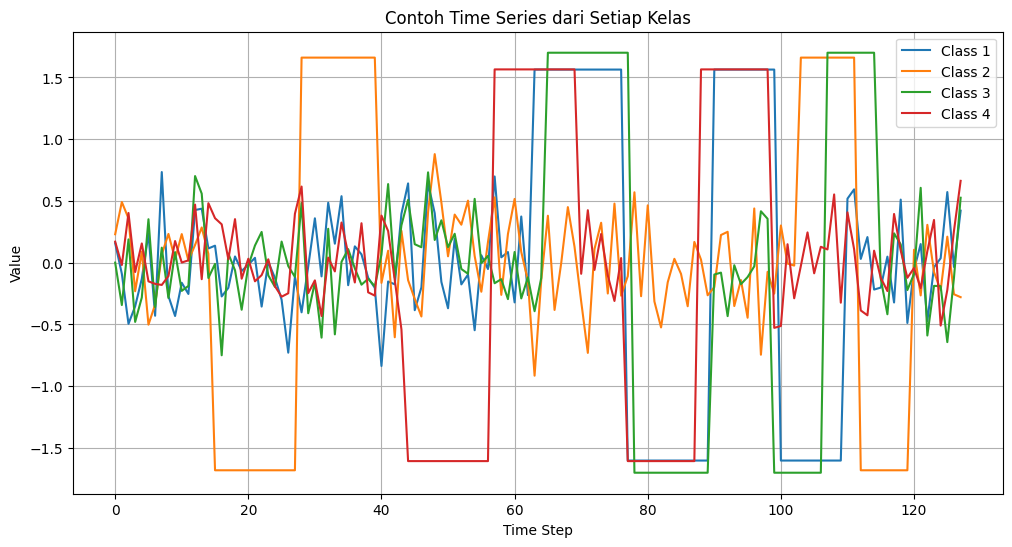

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

unique_classes = np.unique(y_train)

for cls in unique_classes:
    idx = np.where(y_train == cls)[0][0]   # ambil 1 contoh dari kelas tsb
    plt.plot(X_train[idx], label=f"Class {cls}")

plt.title("Contoh Time Series dari Setiap Kelas")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()


# 5. Cek Missing Values

In [9]:
print("Ada NaN di train?", np.isnan(X_train).any())
print("Ada NaN di test? ", np.isnan(X_test).any())


Ada NaN di train? False
Ada NaN di test?  False


“Ada NaN di train? False” → Tidak ada nilai hilang (NaN) di data latih ✔️

“Ada NaN di test? False” → Tidak ada nilai hilang (NaN) di data uji ✔️

Model tidak akan error akibat nilai NaN.

Tidak perlu melakukan imputasi atau pembersihan tambahan.

Data bersih → performa model lebih stabil dan konsisten.

# 6. Cek Konsistensi Panjang Time Series

In [10]:
lengths = [len(x) for x in X_train]
print("Semua panjang sama?", len(set(lengths)) == 1)


Semua panjang sama? True


Semua fitur pada setiap sampel memiliki panjang (jumlah kolom) yang konsisten.

Tidak ada baris yang memiliki jumlah fitur lebih sedikit atau lebih banyak.

Dataset valid, tidak korup, dan aman untuk masuk ke model machine learning.

In [11]:
def count_features_ts(path):
    with open(path, "r") as f:
        for line in f:
            line = line.strip()

            # mulai membaca setelah @data
            if line.lower() == "@data":
                break

        # ambil satu baris data pertama
        for line in f:
            line = line.strip()
            if ":" in line:  # format: data,data,data : label
                features_str, label = line.split(":")
                features = features_str.split(",")
                return len(features)

# ====== CEK FITUR ======
train_path = "TwoPatterns/TwoPatterns_TRAIN.ts"
test_path = "TwoPatterns/TwoPatterns_TEST.ts"

print("Jumlah fitur TRAIN :", count_features_ts(train_path))
print("Jumlah fitur TEST  :", count_features_ts(test_path))


Jumlah fitur TRAIN : 128
Jumlah fitur TEST  : 128


In [12]:
import numpy as np

def detect_outliers_zscore(X, threshold=3):
    """
    X : numpy array (n_samples, n_features)
    threshold : batas Z-Score (default = 3)
    """
    mean = np.mean(X, axis=0)
    std  = np.std(X, axis=0)

    # hitung z-score
    z_scores = (X - mean) / std

    # boolean mask outlier
    outlier_mask = np.abs(z_scores) > threshold

    # jumlah outlier per sample
    outlier_count_per_sample = np.sum(outlier_mask, axis=1)

    return outlier_mask, outlier_count_per_sample

# ===== JALANKAN =====
outlier_mask, outlier_count = detect_outliers_zscore(X_train)

# total sampel yang mengandung outlier
n_outlier_samples = np.sum(outlier_count > 0)

print("Total sampel TRAIN:", len(X_train))
print("Sampel yang mengandung outlier :", n_outlier_samples)
print("Persentase:", (n_outlier_samples / len(X_train)) * 100, "%")


Total sampel TRAIN: 1000
Sampel yang mengandung outlier : 127
Persentase: 12.7 %
